# Perfilado de segmentos y recomendaciones

Sintetiza los hallazgos de los notebooks anteriores en una descripción operativa de cada segmento, con palancas de marketing concretas.

**Autor:** Andrés Fernando Gómez Rojas

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.clustering import CLUSTER_NAMES

df = pd.read_pickle('../data/processed/df_clustered.pkl')
pd.set_option('display.float_format', '{:.2f}'.format)

## Tabla resumen de los cuatro segmentos

In [2]:
num_vars = ['n_sessions', 'totals.hits', 'totals.pageviews',
            'hits_per_session', 'pageviews_per_session',
            'bounce_prop', 'weekend_prop', 'device.isMobile']
perfil = df.groupby('cluster_name')[num_vars].mean().round(2)
tamanos = df['cluster_name'].value_counts()
perfil.insert(0, 'n', tamanos)
perfil.insert(1, 'pct', (tamanos / len(df) * 100).round(1))
perfil

,n,pct,n_sessions,totals.hits,totals.pageviews,hits_per_session,pageviews_per_session,bounce_prop,weekend_prop,device.isMobile
cluster_name,,,,,,,,,,
Desktop Engaged,4247,42.50,1.65,32.32,25.09,25.21,19.72,0.01,0.01,0.00
Desktop Frecuente,3819,38.20,6.36,9.07,7.65,2.14,1.82,0.15,0.10,0.00
Mobile Users,957,9.60,3.28,18.05,14.83,12.69,10.42,0.17,0.25,1.00
Weekend Warriors,973,9.70,1.69,33.42,26.00,25.44,19.90,0.03,0.85,0.01


## Composición categórica

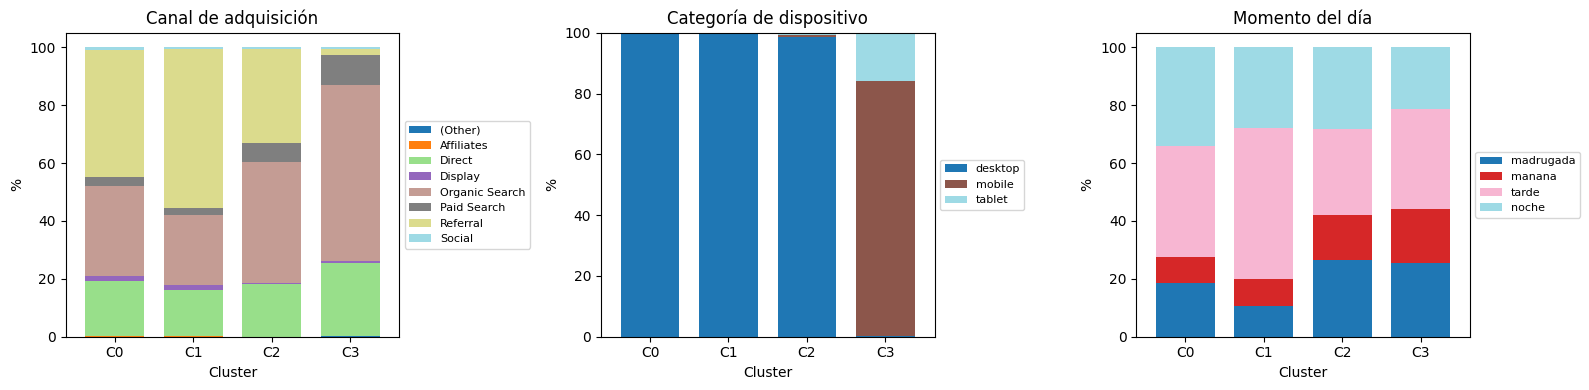

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, titulo in zip(
    axes, ['channelGrouping', 'device.deviceCategory', 'part_of_day'],
    ['Canal de adquisición', 'Categoría de dispositivo', 'Momento del día']
):
    pct = pd.crosstab(df['cluster'], df[col], normalize='index') * 100
    pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75)
    ax.set_title(titulo)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('%')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    ax.set_xticklabels([f'C{i}' for i in range(4)], rotation=0)
plt.tight_layout()
plt.savefig('../figures/03_composicion_categorica.png', dpi=130, bbox_inches='tight')
plt.show()

## Descripción de cada segmento

### C0 — Desktop Engaged (42.5%, 4.247 visitantes)

Visitas pocas pero muy profundas. Promedio de 1.6 sesiones con 25 hits por sesión. Bounce rate de apenas 1%. Todos en desktop, principalmente Macintosh y Windows. Casi cero actividad de fin de semana. Canales dominantes: Direct y Organic Search.

Este es el segmento que efectivamente convierte. No necesita atracción adicional; ya está en el sitio. La inversión va en optimización de conversión: A/B testing del checkout, mejora de páginas de producto, programa de loyalty para los que sí compran.

### C1 — Desktop Frecuente Superficial (38.2%, 3.819 visitantes)

Promedio de 6.4 sesiones por visitante pero solo 2 hits por sesión. Bounce rate del 15%. Visitas cortas y repetidas. 55% llegan por Referral, lo que sugiere lectores que vienen de blogs, comparadores o reviews.

Este es el segmento con mayor potencial de crecimiento. Están investigando, comparando, volviendo. La estrategia es nurturing por contenido educativo: guías de producto, comparativas, email marketing con valor antes de la promoción. Retargeting con contenido, no con descuento.

### C2 — Weekend Warriors (9.7%, 973 visitantes)

Engagement equivalente al C0 (25 hits por sesión, bounce 3%) pero concentrado en fin de semana: 85% de sus visitas son sábado o domingo. El test post-hoc confirma que en intensidad de engagement no difieren estadísticamente de C0; su única diferencia significativa es el momento de la semana.

Funcionalmente son power users con disponibilidad de fin de semana. Campañas programadas viernes a domingo, mayor inversión en paid search en esos días, contenido visual y de ocio. El supuesto interno debería ser que se comportarán como los Desktop Engaged si la oferta llega en el momento correcto.

### C3 — Mobile Users (9.6%, 957 visitantes)

100% en mobile o tablet. Engagement medio (12 hits por sesión) pero bounce rate del 17%, 17 veces más alto que el de C0. Mix de iOS y Android casi por mitades. Mayor proporción de Paid Search (10%) que cualquier otro cluster.

La lectura crítica: se está pagando para llevar tráfico mobile a una experiencia que no convierte. Antes de cualquier campaña, hay un trabajo de UX y rendimiento que hacer. Auditoría de Core Web Vitals, peso de imágenes, flujo de checkout mobile. Mientras eso no se arregle, aumentar inversión de adquisición en mobile es tirar dinero.

## Tabla de recomendaciones por segmento

In [4]:
recomendaciones = pd.DataFrame([
    {
        'Segmento': 'C0 Desktop Engaged',
        'Objetivo principal': 'Conversión y ticket medio',
        'Acción': 'CRO sobre páginas de producto, programa de loyalty',
        'Canal': 'Direct, email transaccional',
        'KPI': 'Tasa de conversión, AOV',
    },
    {
        'Segmento': 'C1 Desktop Frecuente',
        'Objetivo principal': 'Activación y profundización',
        'Acción': 'Email nurturing con contenido educativo, retargeting con guías',
        'Canal': 'Email, Display, contenido SEO',
        'KPI': 'Sesiones por visitante, hits por sesión',
    },
    {
        'Segmento': 'C2 Weekend Warriors',
        'Objetivo principal': 'Captura en ventana de oportunidad',
        'Acción': 'Campañas programadas viernes-domingo, ofertas tiempo limitado',
        'Canal': 'Paid Search con dayparting, push notifications',
        'KPI': 'Conversión en fin de semana, CPA',
    },
    {
        'Segmento': 'C3 Mobile Users',
        'Objetivo principal': 'Optimización de experiencia antes de inversión',
        'Acción': 'Auditoría mobile-first, mejora de Core Web Vitals',
        'Canal': 'Producto, no marketing',
        'KPI': 'Bounce rate mobile, tiempo de carga',
    },
])
recomendaciones

,Segmento,Objetivo principal,Acción,Canal,KPI
0,C0 Desktop Engaged,Conversión y ticket medio,"CRO sobre páginas de producto, programa de loy...","Direct, email transaccional","Tasa de conversión, AOV"
1,C1 Desktop Frecuente,Activación y profundización,"Email nurturing con contenido educativo, retar...","Email, Display, contenido SEO","Sesiones por visitante, hits por sesión"
2,C2 Weekend Warriors,Captura en ventana de oportunidad,"Campañas programadas viernes-domingo, ofertas ...","Paid Search con dayparting, push notifications","Conversión en fin de semana, CPA"
3,C3 Mobile Users,Optimización de experiencia antes de inversión,"Auditoría mobile-first, mejora de Core Web Vitals","Producto, no marketing","Bounce rate mobile, tiempo de carga"


## Exportación final

Generamos un CSV con cada visitante etiquetado, listo para integrar a CRM o herramientas de email marketing.

In [5]:
columnas_export = [
    'fullVisitorId', 'channelGrouping', 'device.deviceCategory',
    'n_sessions', 'totals.hits', 'totals.pageviews',
    'bounce_prop', 'weekend_prop', 'cluster', 'cluster_name',
]
df[columnas_export].to_csv('../data/processed/customers_segmentados.csv', index=False)
print(f'Exportados {len(df)} visitantes con etiqueta de cluster')

Exportados 9996 visitantes con etiqueta de cluster


## Limitaciones y siguientes pasos

El análisis actual permite agrupar visitantes según comportamiento de engagement, pero no según valor de negocio. Sin variables de conversión, revenue o LTV, los segmentos describen cómo interactúan los usuarios con el sitio, no cuánto valen. Una segmentación complementaria por RFM o LTV requeriría datos transaccionales que no están en este dataset.

Antes de operacionalizar las recomendaciones, sería deseable: validar cualitativamente los segmentos con el equipo de marketing (revisar 30-50 visitantes de cada cluster y confirmar que la descripción coincide con lo que ven en su día a día), añadir datos de conversión para enriquecer los perfiles con métricas de valor, y establecer un proceso de reentrenamiento trimestral con monitoreo de drift por Population Stability Index.